Fonte: https://www.datacamp.com/pt/tutorial/decision-tree-classification-python

https://medium.com/data-science/decision-tree-classifier-explained-a-visual-guide-with-code-examples-for-beginners-7c863f06a71e

https://blog.somostera.com/data-science/arvores-de-decisao

Honestamente, depois que cheguei até aqui, acho que deveria ter começado por ele, não por sua complexidade, mas por quão facil é entendê-lo e como ele pode ajudar a intuir os outros, então se fosse para reorganizar a **Árvore de Decisão**, seria, sem dúvida, a primeira da lista. Antes de nos perdermos em probabilidades, margens geométricas ou funções logísticas, a árvore de decisões é muito mais familiar

**Um fluxograma de perguntas e respostas**, o único modelo que pensa de forma fundamentalmente humana. É um modelo "caixa branca", onde cada decisão é explicito e pode ser explicado de maneira simples

Vamos ver como ela funciona, nosso contexto agora é decidir se um banco deve ou não aprovar um pedido de crédito.

Imagine um gerente de crédito experiente, Sr. Roberto. Ele precisa treinar um novo analista, mas sua própria experiência é baseada em anos de intuição. Para tornar o processo claro e replicável, ele precisa mapear seu raciocínio em uma série de perguntas.

**Passo 1: A pergunta mais importante (O Nó Raiz)**

Sr. Roberto pensa: "Qual é a primeira pergunta que eu posso fazer para separar os bons dos maus pagadores?". Ele percebe que a informação mais impactante é se o cliente possui uma fonte de renda. 

Essa se torna a primeira pergunta no topo do seu fluxograma. É a raiz da sua árvore.

- Pergunta: *O cliente tem uma fonte de renda?*
    - **Sim**: O cliente para para o próximo estágio da análise
    - **Não**: Risco alto. A decisão deve ser: **NEGAR**

**Passo 2: Criadno os ramos (Nós Internos)**

Agora, para o grupo que respondeu "Sim', o Sr. Roberto precisa de uma segunda pergunta, Ele não vai usar a mesma lógica para todos; ele está focando em um grpo mais promissor. Talvez, pessoas com menos dívidas:

- Pergunta (para quem tem renda): *O nível de dívida atual é alto*
    - **Sim**: Esse grupo é arriscado. Precisamos decidir.
    - **Não**: Este grupo é de baixo risco. A chance de aprovar deve ser mais alta.

**Passo 3: Chegando às folhas (Decisão)**

O fluxograma continua se ramificando.

- Para o grupo com renda estável e dívida baixa, a decisão é simples: **APROVAR**

- Para o grupo com renda estável mas dívida alta, o Sr Roberto decide mais uma pergunta para desempatar, como: "O cliente possui um imóvel como garantia?".
    - **Sim**: O risco é mitigado pela garantia. A decisão é **APROVAR**. Outra folha

    - **Não**: Renda estável, mas alta dívida e sem garantia? a decisão parece ser **NEGAR**. (Outra folha)

**O fluxograma final:**

No final, o Sr. Roberto criou um fluxograma, um guia passo a passo que qualquer um pode seguir.

Quando um novo pedido de crédito chega, qualquer pessoa com esse roteiro chega na decisão final e justificada





### 3.5.2 Intuição 

Imagine que você é o Sr. Roberto e precisa decidir se aprova ou não um pedido de crédito. Você tem as informações do cliente:

- Renda anual: $50.000
- Dívida Atual: $10.000
- Histórico de Crédito: Bom
- Empregado: Sim
- Garantia: Sim

Pergunta: Aprovar (+) ou Rejeitar (-) o crédito?

Como vimos a anatomia de uma árvore:

- Root Node:
    - Primeiro nó no topo
    - Representa a feature mais importante
    - De onde todas as decisões começam

- Internal Nodes:
    - Fazem testes/perguntas sobre features
    - Têm pelo menos 2 ramos saindo
    - Cada ramo representa uma resposta possível

- Branches:
    - Conectam os nós
    - Representam as respostas possíveis (Sim/Não, valores)

- Leaf Nodes:
    - Nós finais, sem ramos saindo
    - Contêm a decisão final
    - Exemplo: "Aprovar", "Rejeitar"

- Depth:
    - Número de níves da árvore
    - Quanto mais profunta mais complexa é a árvore

O algoritmo usa uma estratégia greedy (Guloso), ela é construida assim:

1. Escolhe a 'melhor' feature para dividr os dados
"melhor" = aquela que mais reduz impureza

2. Divide os dados baseado nessa feature

3. Repete recursivamente para cada subconjunto

4. Para:
    - quando todos os exemplos são da mesma classe (puro)
    - Não há mais features para dividir
    - Atinge profundidade máxima
    - Conjunto se torna muito pequeno (min_samples_split)

- IMPUREZA: Mede o quão misturadas estão as classes
    - Impureza = 0: Todos na mesma classe (puro)

**Medindo a impureza:"**

- Gini impurity

$Gini = 1 - \sum(P_i)^2$

eg: 
- [50 aprovados, 50 rejeitados]
    - $Gini = 1 - (0.5^2 + 0.5^2) = 0.5$ (Máxima impureza para 2 classes)

- [90 aprovados, 10 rejeitados]
- $Gini = 1- (0.9^2 + 0.1^2) = 0.18$

- Shannon Entropy

$Entropy = -\sum P_i\log_2(P_i)$

e.g. 
- [50 aprovados, 50 rejeitados]
    - $-(0.5\times\log(0.5) + 0.5\times\log(0.5)) = 1$ (máximo)

- Information Gain

$Gain = Impureza(antes) - Impureza(depois da divisão)

- Quanto a divisão reduziu da impureza

---

**Vamos visualizar**!

# =============================
#Bibliotecas
# =============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

In [40]:
# Dessa vez, vamos gerar os dados para interpretarmos
np.random.seed(42)
n_samples = 100

age = np.random.randint(18, 70, n_samples)
income = np.random.randint(20000, 120000, n_samples)
debt = np.random.randint(0, 50000, n_samples)
employed = np.random.choice([0, 1], n_samples, p=[0.7, 0.3])  # 0: No, 1: Yes
credit_score = np.random.choice(['Good', 'Fair', 'Poor'], n_samples, p=[0.4, 0.4, 0.2])

approved = []
for i in range(n_samples):
    score = 0

    if income[i] > 60000:
        score += 3
    if income[i] > 40000:
        score += 2
    else:
        score += 1

    if debt[i] < 15000:
        score += 3
    elif debt[i] < 30000:
        score += 1

    if employed[i] == 1:
        score += 2
        
    if credit_score[i] == 'Good':
        score += 3
    elif credit_score[i] == 'Fair':
        score += 1
  
    approved.append(1 if score >= 6 else 0)

df = pd.DataFrame({
    'Age': age,
    'Income': income,
    'Debt': debt,
    'Employed': employed,
    'Credit_Score': credit_score,
    'Approved': approved
})

print("Total de registros:", len(df))
print(f"\nDistribuição das decisões:")
print(df['Approved'].value_counts(normalize=True))


Total de registros: 100

Distribuição das decisões:
Approved
1    0.71
0    0.29
Name: proportion, dtype: float64


In [41]:
# Calcular Gini Impurity
def gini_impurity(y):
    if len(y) == 0:
        return 0
    proportions = np.bincount(y) / len(y)
    return 1 - np.sum(proportions ** 2)

def entropy(y):
    if len(y) == 0:
        return 0
    proportions = np.bincount(y) / len(y)
    proportions = proportions[proportions > 0]
    return -np.sum(proportions * np.log2(proportions))

gini_initial = gini_impurity(df['Approved'])
entropy_initial = entropy(df['Approved'])
print(f"Gini Impurity (Initial): {gini_initial}")
print(f"Entropy (Initial): {entropy_initial}")
print(f"\nTemos {np.sum(df['Approved'])} aprovações e {len(df) - np.sum(df['Approved'])} rejeições.")

Gini Impurity (Initial): 0.41180000000000005
Entropy (Initial): 0.8687212463394045

Temos 71 aprovações e 29 rejeições.


In [42]:
y = df['Approved'].values
threshold_income = 60000
high_income_mask = df['Income'] > threshold_income
low_income_mask = ~high_income_mask

# Grupo: Income > 60000
high_income_approved = y[high_income_mask]
gini_high = gini_impurity(high_income_approved)
print(f"\nGrupo 1 (Income > ${threshold_income:,}):")
print(f"   Total: {len(high_income_approved)} pessoas")
print(f"   Aprovados: {np.sum(high_income_approved)} ({np.mean(high_income_approved)*100:.1f}%)")
print(f"   Gini: {gini_high:.4f}")

# Grupo: Income <= 60000
low_income_approved = y[low_income_mask]
gini_low = gini_impurity(low_income_approved)
print(f"\nGrupo 2 (Income <= ${threshold_income:,}):")
print(f"   Total: {len(low_income_approved)} pessoas")
print(f"   Aprovados: {np.sum(low_income_approved)} ({np.mean(low_income_approved)*100:.1f}%)")
print(f"   Gini: {gini_low:.4f}")

# Calcular Gini após a divisão
gini_after_split = (len(high_income_approved) / len(y)) * gini_high + (len(low_income_approved) / len(y)) * gini_low
print(f"\nGini após a divisão: {gini_after_split:.4f}")
print(f"\nGanho: {gini_initial - gini_after_split:.4f}")


Grupo 1 (Income > $60,000):
   Total: 60 pessoas
   Aprovados: 57 (95.0%)
   Gini: 0.0950

Grupo 2 (Income <= $60,000):
   Total: 40 pessoas
   Aprovados: 14 (35.0%)
   Gini: 0.4550

Gini após a divisão: 0.2390

Ganho: 0.1728


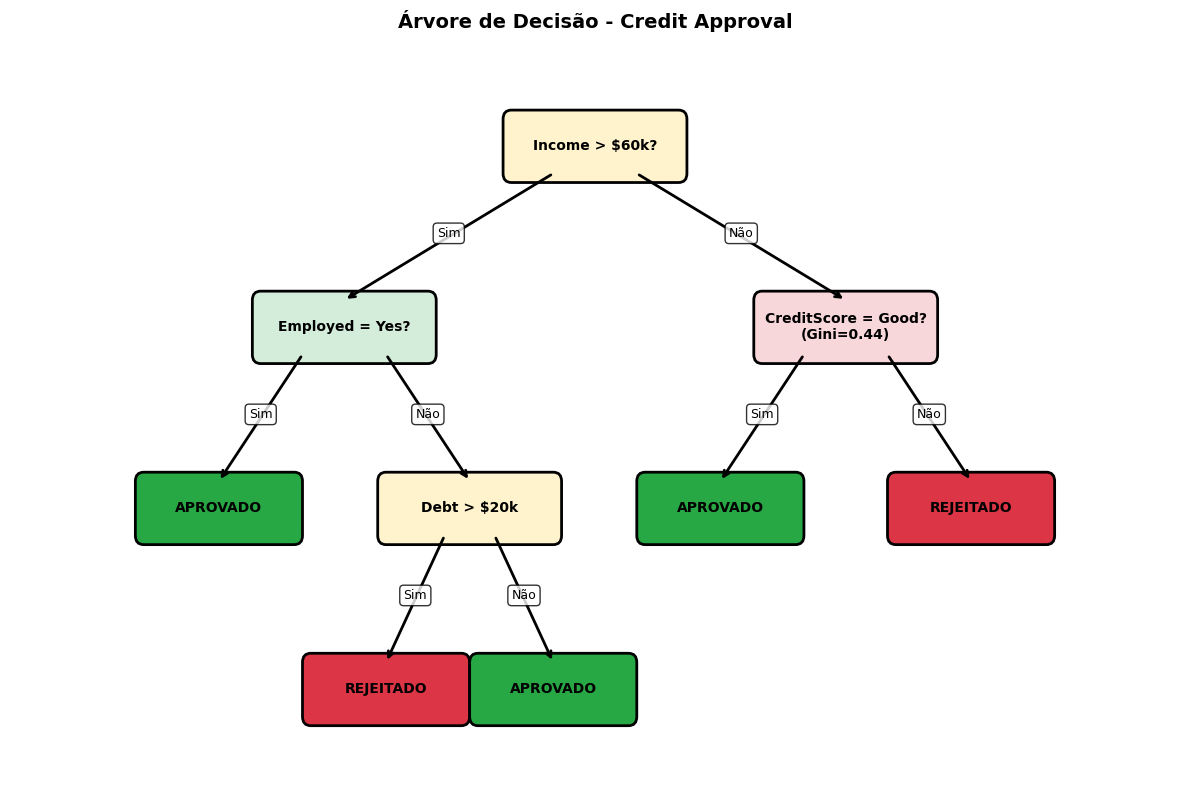

In [48]:
# Desenho da árvore de decisão

def draw_node(ax, x, y, text, width=2, height=0.6, color='lightblue'):
    box = FancyBboxPatch((x-width/2, y-height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10, 
           fontweight='bold', wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle='->', lw=2, color='black'))
    if label:
        mid_x, mid_y = (x1+x2)/2, (y1+y2)/2
        ax.text(mid_x, mid_y, label, ha='center', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


fig, ax = plt.subplots(figsize=(12, 8))
# Root Node
draw_node(ax, 7, 7, 'Income > $60k?', color='#fff3cd')

# Ramo esquerdo (Sim)
draw_arrow(ax, 6.5, 6.7, 4, 5.3, 'Sim')
draw_node(ax, 4, 5, 'Employed = Yes?', color='#d4edda')

# Sub-ramos esquerda
draw_arrow(ax, 3.5, 4.7, 2.5, 3.3, 'Sim')
draw_node(ax, 2.5, 3, 'APROVADO', width=1.8, color='#28a745')

draw_arrow(ax, 4.5, 4.7, 5.5, 3.3, 'Não')
draw_node(ax, 5.5, 3, 'Debt > $20k', color='#fff3cd')

draw_arrow(ax, 5.2, 2.7, 4.5, 1.3, 'Sim')
draw_node(ax, 4.5, 1, 'REJEITADO', width=1.8, color='#dc3545')

draw_arrow(ax, 5.8, 2.7, 6.5, 1.3, 'Não')
draw_node(ax, 6.5, 1, 'APROVADO', width=1.8, color='#28a745')

# Ramo direito (Não)
draw_arrow(ax, 7.5, 6.7, 10, 5.3, 'Não')
draw_node(ax, 10, 5, 'CreditScore = Good?\n(Gini=0.44)', color='#f8d7da')

draw_arrow(ax, 9.5, 4.7, 8.5, 3.3, 'Sim')
draw_node(ax, 8.5, 3, 'APROVADO', width=1.8, color='#28a745')

draw_arrow(ax, 10.5, 4.7, 11.5, 3.3, 'Não')
draw_node(ax, 11.5, 3, 'REJEITADO', width=1.8, color='#dc3545')

ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Árvore de Decisão - Credit Approval', 
            fontsize=14, fontweight='bold', pad=20)


plt.tight_layout()
plt.show()

### 3.5.3 Formulação Formal

**Entrada**

1. Conjunto de treinamento de n amostras em pares $D=\{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), ..., (x^{(n)}, y^{(n)})\}$

    onde:

    - $x^{(i)}$: vetor de d features ($x^{(i)} = (x^{(i)}_1, x^{(i)}_2, ..., x^{(i)}_d)$), portanto $x^{(i)} \in \mathbb{R}^d$

    - $y^{(i)}$: rótulo de classe, $y^{(i)} \in C = \{c_1, c_2, ..., c_k\}$ para classificação

**Processamento**

O algoritmo de árvore de decisão funciona recursivamente dividindo o espaço de características.

**1. Critérios de Impureza**

**Entropia**: Para um conjunto $S$ com $k$ classes:

$H(S) = -\sum_{i=1}^{k} p_i \log_2(p_i)$

onde $p_i$ é a proporção de amostras da classe $i$ em $S$.

**Gini Impurity**: 

$Gini(S) = 1 - \sum_{i=1}^{k} p_i^2$

**2. Information Gain**

Para uma feature $A$ que divide $S$ em subconjuntos $S_1, S_2, ..., S_m$:

$IG(S, A) = H(S) - \sum_{j=1}^{m} \frac{|S_j|}{|S|} H(S_j)$

**3. Algoritmo de Construção**

``` code
função BuildTree(S, Features):
    se S é puro (todas as amostras têm a mesma classe):
        retorna folha com essa classe
    
    se Features é vazio:
        retorna folha com classe majoritária em S
    
    seleciona feature A que maximiza Information Gain
    cria nó com teste em A
    
    para cada valor v de A:
        S_v = subconjunto de S onde A = v
        se S_v é vazio:
            adiciona folha com classe majoritária em S
        senão:
            adiciona subárvore BuildTree(S_v, Features - {A})
```

**4. Critérios de Parada**

- Profundidade máxima atingida
- Número mínimo de amostras por folha
- Information Gain mínimo
- Nó puro (todas amostras da mesma classe)

**Saída - Classificação**

- **Estrutura da Árvore**: Conjunto de nós internos (testes) e folhas (predições)

- **Predição**: Para uma nova amostra $x^{new}$:
  1. Começar na raiz
  2. Aplicar o teste do nó atual em $x^{new}$
  3. Seguir o ramo correspondente ao resultado
  4. Repetir até chegar a uma folha
  5. Retornar a classe da folha

- **Probabilidades**: Para probabilidades de classe, usar a distribuição das classes na folha

**Poda (Pruning)**

Para evitar overfitting, aplicamos poda:

**Pré-poda**: Parar o crescimento da árvore antecipadamente
- Profundidade máxima
- Número mínimo de amostras por nó
- Information gain mínimo

**Pós-poda**: Remover partes da árvore após construção
- Cost complexity pruning (usado no sklearn)
- Validação cruzada para escolher melhor complexidade

### 3.5.4 Desafio: "From Scratch"

Vamos implementar uma versão simplificada do algoritmo de Árvore de Decisão do zero

In [ ]:
import numpy as np
from collections import Counter

class SimpleDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2, criterion='gini'):
        """
        Implementação simplificada de uma Árvore de Decisão.
        
        Parâmetros:
        -----------
        max_depth: int
            Profundidade máxima da árvore.
        min_samples_split: int
            Número mínimo de amostras necessárias para dividir um nó.
        criterion: str
            Critério para medir a qualidade da divisão ('gini' ou 'entropy').
        """
        pass

    def _calculate_gini(self, y):
        """
        Calcula o índice de Gini para um conjunto de labels.
        
        Parâmetros:
        -----------
        y: array-like
            Labels das classes.
            
        Retorna:
        --------
        float
            Índice de Gini.
        """
        pass

    def _calculate_entropy(self, y):
        """
        Calcula a entropia para um conjunto de labels.
        
        Parâmetros:
        -----------
        y: array-like
            Labels das classes.
            
        Retorna:
        --------
        float
            Entropia.
        """
        pass

    def _calculate_impurity(self, y):
        """
        Calcula a impureza baseada no critério escolhido.
        """
        pass

    def _best_split(self, X, y):
        """
        Encontra a melhor divisão para os dados.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        y: np.ndarray
            Labels das classes.
            
        Retorna:
        --------
        dict
            Dicionário com informações da melhor divisão.
        """
        pass

    def _split_data(self, X, y, feature_index, threshold):
        """
        Divide os dados baseado em uma característica e threshold.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        y: np.ndarray
            Labels das classes.
        feature_index: int
            Índice da característica para divisão.
        threshold: float
            Valor threshold para divisão.
            
        Retorna:
        --------
        tuple
            Dados divididos (X_left, X_right, y_left, y_right).
        """
        pass

    def _build_tree(self, X, y, depth=0):
        """
        Constrói a árvore recursivamente.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        y: np.ndarray
            Labels das classes.
        depth: int
            Profundidade atual.
            
        Retorna:
        --------
        dict
            Nó da árvore.
        """
        pass

    def fit(self, X, y):
        """
        Treina a árvore de decisão.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        y: np.ndarray
            Labels das classes.
        """
        pass

    def _predict_sample(self, sample, node):
        """
        Faz predição para uma única amostra.
        
        Parâmetros:
        -----------
        sample: np.ndarray
            Amostra para predição.
        node: dict
            Nó atual da árvore.
            
        Retorna:
        --------
        class
            Classe predita.
        """
        pass

    def predict(self, X):
        """
        Faz predições para um conjunto de dados.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
            
        Retorna:
        --------
        np.ndarray
            Predições.
        """
        pass

    def score(self, X, y):
        """
        Calcula a acurácia do modelo.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        y: np.ndarray
            Labels verdadeiros.
            
        Retorna:
        --------
        float
            Acurácia do modelo.
        """
        pass

In [55]:
# Dados para Teste - Credit Approval Dataset
# ==================================================
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Fetch dataset
credit_approval = fetch_ucirepo(id=27) 

# Data (as pandas dataframes) 
X = credit_approval.data.features 
y = credit_approval.data.targets

# Simplificar dataset para fins didáticos
# Selecionar algumas features importantes e tratar valores ausentes
X_simple = X[['A2', 'A3', 'A8', 'A11', 'A14', 'A15']].copy()
X_simple.columns = ['Age', 'Years_Employed', 'Debt_to_Income', 'Credit_Score', 'Income', 'Debt']

# Tratar valores ausentes - substituir por mediana para numéricos
for col in X_simple.columns:
    if X_simple[col].dtype in ['float64', 'int64']:
        X_simple[col] = pd.to_numeric(X_simple[col], errors='coerce')
        X_simple[col] = X_simple[col].fillna(X_simple[col].median())

# Remover amostras com muitos valores ausentes
X_simple = X_simple.dropna()
y_simple = y.loc[X_simple.index]

# Converter target para binário (aprovado/negado)
le = LabelEncoder()
y_binary = le.fit_transform(y_simple.values.ravel())

print(f"Dataset shape: {X_simple.shape}")
print(f"Classes: {le.classes_}")
print(f"Distribuição das classes: {np.bincount(y_binary)}")

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_simple.values, y_binary, test_size=0.2, random_state=42
)

Dataset shape: (690, 6)
Classes: ['+' '-']
Distribuição das classes: [307 383]


### 3.5.5 Usando SKlearn

In [56]:
# Carregando os dados (novamente)
# ==================================================
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Fetch dataset
credit_approval = fetch_ucirepo(id=27) 

# Data (as pandas dataframes) 
X = credit_approval.data.features 
y = credit_approval.data.targets

# Simplificar dataset para fins didáticos
X_simple = X[['A2', 'A3', 'A8', 'A11', 'A14', 'A15']].copy()
X_simple.columns = ['Age', 'Years_Employed', 'Debt_to_Income', 'Credit_Score', 'Income', 'Debt']

# Tratar valores ausentes
for col in X_simple.columns:
    if X_simple[col].dtype in ['float64', 'int64']:
        X_simple[col] = pd.to_numeric(X_simple[col], errors='coerce')
        X_simple[col] = X_simple[col].fillna(X_simple[col].median())

X_simple = X_simple.dropna()
y_simple = y.loc[X_simple.index]

# Converter target para binário
le = LabelEncoder()
y_binary = le.fit_transform(y_simple.values.ravel())

print(f"Dataset shape: {X_simple.shape}")
print(f"Classes: {le.classes_}")
print(f"Taxa de aprovação: {np.mean(y_binary)*100:.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X_simple.values, y_binary, test_size=0.2, random_state=42
)

Dataset shape: (690, 6)
Classes: ['+' '-']
Taxa de aprovação: 55.51%


In [ ]:
# =================================================
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [77]:
# ===================================================
# 1. Implementação Básica

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
predictions = tree.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Acurácia: {accuracy*100:.2f}%")


Acurácia: 67.39%


In [81]:
# =================================================
# 2. Visualização do Modelo

tree_small = DecisionTreeClassifier(max_depth=3, random_state=42) #melhorar visualização
tree_small.fit(X_train, y_train)

print("\nRegras da Árvore de Decisão:")
rules = export_text(tree_small, feature_names=list(X_simple.columns))
print(rules)


Regras da Árvore de Decisão:
|--- Credit_Score <= 2.50
|   |--- Debt_to_Income <= 1.21
|   |   |--- Debt <= 5500.00
|   |   |   |--- class: 1
|   |   |--- Debt >  5500.00
|   |   |   |--- class: 0
|   |--- Debt_to_Income >  1.21
|   |   |--- Debt <= 186.50
|   |   |   |--- class: 1
|   |   |--- Debt >  186.50
|   |   |   |--- class: 0
|--- Credit_Score >  2.50
|   |--- Years_Employed <= 1.42
|   |   |--- Income <= 257.00
|   |   |   |--- class: 1
|   |   |--- Income >  257.00
|   |   |   |--- class: 0
|   |--- Years_Employed >  1.42
|   |   |--- Debt_to_Income <= 0.06
|   |   |   |--- class: 0
|   |   |--- Debt_to_Income >  0.06
|   |   |   |--- class: 0



In [84]:
# =================================================
# 3. Parâmetros Importantes da Árvore de Decisão

# criterion (default='gini')
# - 'gini': Gini impurity
# - 'entropy': Information gain
# - 'log_loss': Log loss

# max_depth (default=None)
# - Profundidade máxima da árvore
# - None = sem limite (pode causar overfitting)

# min_samples_split (default=2)
# - Número mínimo de amostras necessárias para dividir um nó interno

# min_samples_leaf (default=1)
# - Número mínimo de amostras necessárias em uma folha

# max_features (default=None)
# - Número de features a considerar ao procurar a melhor divisão
# - None: usa todas as features

# ccp_alpha (default=0.0)
# - Parâmetro de complexidade para poda de custo mínimo
# =================================================

# Testar diferentes critérios
criteria = ['gini', 'entropy']
results = []

for criterion in criteria:
    dt = DecisionTreeClassifier(criterion=criterion, random_state=42)
    dt.fit(X_train, y_train)
    accuracy = dt.score(X_test, y_test)
    depth = dt.get_depth()
    leaves = dt.get_n_leaves()
    
    results.append((criterion, accuracy, depth, leaves))
    print(f"Critério {criterion:8}: Acurácia = {accuracy*100:5.2f}%, Profundidade = {depth:2d}, Folhas = {leaves:3d}")

# Testar diferentes profundidades máximas
max_depths = [3, 5, 7, 10, None]
print(f"\nTestando diferentes profundidades máximas:")

for max_depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dt.fit(X_train, y_train)
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)
    depth = dt.get_depth()
    leaves = dt.get_n_leaves()
    
    max_depth_str = str(max_depth) if max_depth else "None"
    print(f"Max_depth = {max_depth_str:4}: Train = {train_acc*100:5.2f}%, Test = {test_acc*100:5.2f}%, "
          f"Profundidade Real = {depth:2d}, Folhas = {leaves:3d}")

print(f"""\nNotas: 
      \n - como profundidades menores podem ter melhor generalização (menor overfitting)
      \n - Note como a árvore sem limites de profundade tem 100% de acurácia no treino, mas pior no teste. (decorou os dados)""")

Critério gini    : Acurácia = 67.39%, Profundidade = 15, Folhas = 108
Critério entropy : Acurácia = 72.46%, Profundidade = 15, Folhas = 104

Testando diferentes profundidades máximas:
Max_depth = 3   : Train = 80.80%, Test = 73.91%, Profundidade Real =  3, Folhas =   8
Max_depth = 5   : Train = 84.96%, Test = 76.81%, Profundidade Real =  5, Folhas =  22
Max_depth = 7   : Train = 90.04%, Test = 73.91%, Profundidade Real =  7, Folhas =  47
Max_depth = 10  : Train = 95.83%, Test = 71.74%, Profundidade Real = 10, Folhas =  82
Max_depth = None: Train = 100.00%, Test = 67.39%, Profundidade Real = 15, Folhas = 108

Notas: 
      
 - como profundidades menores podem ter melhor generalização (menor overfitting)
      
 - Note como a árvore sem limites de profundade tem 100% de acurácia no treino, mas pior no teste. (decorou os dados)


In [87]:
## =================================================
# 4. FEATURE IMPORTANCE
# =================================================

tree_analysis = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_analysis.fit(X_train, y_train)

# Importar bibliotecas necessárias
importances = tree_analysis.feature_importances_
indices = np.argsort(importances)[::-1]

# Exibir as características mais importantes (limitado ao número de features disponíveis)
print("Características mais importantes:")
for f in range(min(10, len(importances))):
    print(f"{f + 1}. {X_simple.columns[indices[f]]} ({importances[indices[f]]:.4f})")

# Plotar a importância das características usando gráfico ASCII
print("\n" + "="*60)
print("GRÁFICO DE IMPORTÂNCIA DAS CARACTERÍSTICAS (ASCII)")
print("="*60)

max_bar_length = 50
for f in range(len(importances)):
    idx = indices[f]
    importance = importances[idx]
    bar_length = int(importance * max_bar_length / importances[indices[0]])
    bar = '█' * bar_length
    print(f"{X_simple.columns[idx]:20} | {bar} {importance:.4f}")

print("="*60)

Características mais importantes:
1. Credit_Score (0.4710)
2. Debt (0.1680)
3. Years_Employed (0.1350)
4. Debt_to_Income (0.1197)
5. Age (0.0644)
6. Income (0.0420)

GRÁFICO DE IMPORTÂNCIA DAS CARACTERÍSTICAS (ASCII)
Credit_Score         | ██████████████████████████████████████████████████ 0.4710
Debt                 | █████████████████ 0.1680
Years_Employed       | ██████████████ 0.1350
Debt_to_Income       | ████████████ 0.1197
Age                  | ██████ 0.0644
Income               | ████ 0.0420


In [88]:
# =================================================
# 5. Otimização de Hiperparâmetros com Grid Search
# =================================================

from sklearn.model_selection import GridSearchCV

# Definir espaço de busca
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid search com validação cruzada
dt_grid = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_grid, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Melhores parâmetros
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor score CV: {grid_search.best_score_*100:.2f}%")

# Avaliar no conjunto de teste
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Acurácia no teste: {accuracy_best*100:.2f}%")

# Informações sobre a melhor árvore
print(f"\nInformações da melhor árvore:")
print(f"Profundidade: {best_dt.get_depth()}")
print(f"Número de folhas: {best_dt.get_n_leaves()}")
print(f"Número de nós: {best_dt.tree_.node_count}")

# Relatório detalhado
print(f"\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_best, target_names=['Negado', 'Aprovado']))

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Melhores parâmetros: {'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}
Melhor score CV: 75.36%
Acurácia no teste: 74.64%

Informações da melhor árvore:
Profundidade: 7
Número de folhas: 45
Número de nós: 89

Relatório de Classificação:
              precision    recall  f1-score   support

      Negado       0.86      0.60      0.71        70
    Aprovado       0.69      0.90      0.78        68

    accuracy                           0.75       138
   macro avg       0.77      0.75      0.74       138
weighted avg       0.77      0.75      0.74       138



Análise de Casos Específicos:
Caso 1:
  Características:
    Age: 35
    Years_Employed: 5
    Debt_to_Income: 0.3
    Credit_Score: 700
    Income: 50000
    Debt: 15000
  Predição: Negado
  Probabilidades: Negado=1.000, Aprovado=0.000
  Confiança: 1.000
  ************************************************************
Caso 2:
  Características:
    Age: 25
    Years_Employed: 1
    Debt_to_Income: 0.8
    Credit_Score: 500
    Income: 25000
    Debt: 20000
  Predição: Negado
  Probabilidades: Negado=1.000, Aprovado=0.000
  Confiança: 1.000
  ************************************************************
Caso 3:
  Características:
    Age: 45
    Years_Employed: 10
    Debt_to_Income: 0.2
    Credit_Score: 800
    Income: 80000
    Debt: 16000
  Predição: Negado
  Probabilidades: Negado=1.000, Aprovado=0.000
  Confiança: 1.000
  ************************************************************
Caso 4:
  Características:
    Age: 22
    Years_Employed: 0.5
    Debt_to_Income: 0.9
    Credit_Scor

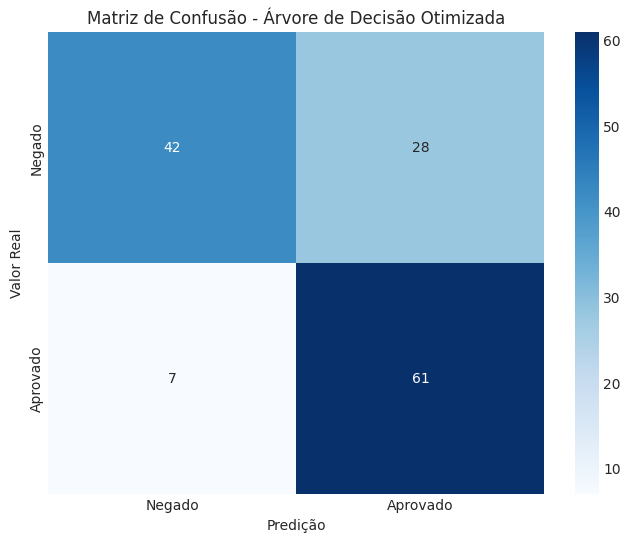

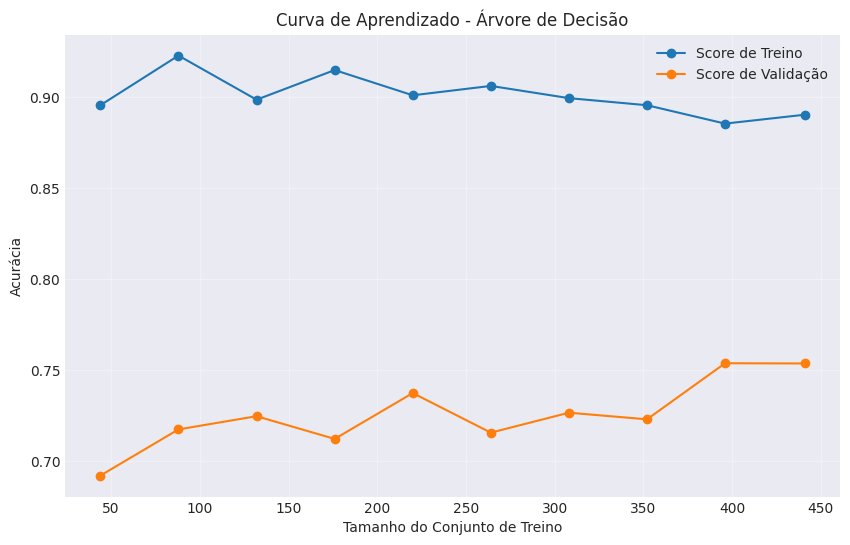

In [89]:
# =================================================
# 5. Análise de Casos Específicos e Interpretabilidade
# =================================================

# Vamos analisar alguns casos específicos para entender as decisões da árvore
test_cases = [
    [35, 5, 0.3, 700, 50000, 15000],  # Caso favorável: idade média, empregado há tempo, baixo debt-to-income
    [25, 1, 0.8, 500, 25000, 20000],  # Caso desfavorável: jovem, pouco tempo empregado, alto debt-to-income
    [45, 10, 0.2, 800, 80000, 16000], # Caso muito favorável: idade madura, muito tempo empregado, baixo debt-to-income
    [22, 0.5, 0.9, 450, 20000, 18000] # Caso muito desfavorável: muito jovem, pouco tempo empregado, muito alto debt-to-income
]

feature_names = ['Age', 'Years_Employed', 'Debt_to_Income', 'Credit_Score', 'Income', 'Debt']

print("Análise de Casos Específicos:")
print("=" * 80)

for i, case in enumerate(test_cases):
    # Fazer predição
    prediction = best_dt.predict([case])[0]
    probabilities = best_dt.predict_proba([case])[0]
    
    # Mostrar o caminho da decisão
    decision_path = best_dt.decision_path([case])
    leaf_id = best_dt.apply([case])[0]
    
    result_names = {0: "Negado", 1: "Aprovado"}
    
    print(f"Caso {i+1}:")
    print(f"  Características:")
    for j, (feature, value) in enumerate(zip(feature_names, case)):
        print(f"    {feature}: {value}")
    
    print(f"  Predição: {result_names[prediction]}")
    print(f"  Probabilidades: Negado={probabilities[0]:.3f}, Aprovado={probabilities[1]:.3f}")
    print(f"  Confiança: {max(probabilities):.3f}")
    print(f"  {'*' * 60}")

# Matriz de confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negado', 'Aprovado'],
            yticklabels=['Negado', 'Aprovado'])
plt.title('Matriz de Confusão - Árvore de Decisão Otimizada')
plt.ylabel('Valor Real')
plt.xlabel('Predição')
plt.show()

# Curva de learning
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_dt, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Score de Treino')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='Score de Validação')
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('Acurácia')
plt.title('Curva de Aprendizado - Árvore de Decisão')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.5.6 Conclusões, Expertises e Dicas Práticas

**Vantagens das Árvores de Decisão:**

1. **Alta Interpretabilidade**: Fácil de entender e explicar para stakeholders não-técnicos
2. **Não Requer Preparação Extensiva dos Dados**: Funciona com dados categóricos e numéricos sem normalização
3. **Captura Relacionamentos Não-Lineares**: Pode modelar interações complexas entre features
4. **Seleção Automática de Features**: Ignora features irrelevantes automaticamente
5. **Robusta a Outliers**: Divisões baseadas em rankings, não em valores absolutos

**Desvantagens:**

1. **Tendência ao Overfitting**: Especialmente com árvores profundas
2. **Instabilidade**: Pequenas mudanças nos dados podem resultar em árvores muito diferentes
3. **Bias para Features com Mais Categorias**: Features com mais valores únicos têm vantagem
4. **Dificuldade com Relacionamentos Lineares**: Pode ser ineficiente para padrões lineares simples
5. **Predições "Escalonadas"**: Só pode prever valores que existem no conjunto de treino
